# 07 · 解决数据泄漏

> O2O 优惠券个性化投放项目 —— 第 7 步

---

## 本节目标

第 06 节证明了「删特征治不了本」。本节给出**真正能截断泄漏**的修复方案，并实测修复效果。

## 修复的两个着力点

泄漏的根因是**特征的计算范围越界**，所以修复也必须打在范围上：

| # | 修复项 | 从 | 到 |
|---|---|---|---|
| ① | **切分方式** | `train_test_split` 随机切分 | **按时间切分**（1-5 月 / 6 月 / 7 月） |
| ② | **聚合范围** | 全量数据 `groupby` | **只在训练段** `groupby`，各段特征值全部来自训练段历史 |

### 这两条各自堵住了什么

- **时间切分** → 堵住**重叠泄漏**：验证段/测试段的数据不再出现在训练集里，
  同一 user/merchant/coupon 不会「跨集被记住」。
- **聚合只在训练段** → 堵住**自指泄漏 + 目标泄漏**：
  训练段的特征不含验证段/测试段的未来信息；
  验证段/测试段的特征**完全来自训练段历史**，不含自身行的核销结果。

> ### 为什么这样就截断了目标泄漏
>
> 关键不在于「删掉 `mean_interval`」，而在于**它的计算范围被限制在训练段**：
> 对验证段某一行来说，该用户的 `mean_interval` 是从**训练段历史**里算出来的，
> 里头**不包含这一行自己的核销结果**。模型没法再从特征里读出这一行的答案。

---

> **本节定位**：这是一次**最小修复实验**——特征定义与第 03 节完全一致（包括那个
> 退化的 `coupon_used_rate`），**只改数据范围和切分方式**。这样 A 组（第 06 节）
> 与 D 组（本节）的差异就纯粹归因于「范围 + 切分」这一项修复。

In [1]:
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve)
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)
pd.set_option('display.unicode.east_asian_width', True)

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['savefig.bbox'] = 'tight'

ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    if (cand / '.git').exists():
        ROOT = cand
        break

OUT_DIR = ROOT / 'data_out'
FIG_DIR = ROOT / 'results' / 'figures'
TAB_DIR = ROOT / 'results' / 'tables'
MODEL_DIR = OUT_DIR / 'models_v1'

C_MAIN, C_ALT, C_WARN, C_GREY = '#2F6F9F', '#E08A3C', '#C0504D', '#8C8C8C'

with open(MODEL_DIR / 'best_params_v1.json', encoding='utf-8') as f:
    BEST_PARAMS = json.load(f)

## 1. 时间切分

```
训练段 : 领券月 1-5 月   -> 算画像 + 训练模型
验证段 : 领券月 6 月     -> 诚实评估（特征全部来自训练段历史）
测试段 : 7 月 (test.csv) -> 最终预测
```

这样才模拟真实场景：**用历史预测未来**。

In [2]:
df_train = pd.read_csv(OUT_DIR / 'clean_train.csv', parse_dates=['date_received', 'date'])
df_test = pd.read_csv(OUT_DIR / 'clean_test.csv', parse_dates=['date_received', 'date'])

train_seg = df_train[df_train['receive_month'] <= 5].copy()
val_seg = df_train[df_train['receive_month'] == 6].copy()
test_seg = df_test.copy()

print('时间切分结果：')
for name, seg in [('训练段 1-5 月', train_seg), ('验证段 6 月', val_seg), ('测试段 7 月', test_seg)]:
    pos = seg['class'].mean() * 100 if name != '测试段 7 月' else float('nan')
    print(f'  {name:<14}: {len(seg):>9,} 行   正样本率 {pos:.2f}%' if name != '测试段 7 月'
          else f'  {name:<14}: {len(seg):>9,} 行   (无标签)')

时间切分结果：
  训练段 1-5 月     :   865,468 行   正样本率 5.93%
  验证段 6 月       :    81,811 行   正样本率 6.99%
  测试段 7 月       :   100,669 行   (无标签)


## 2. 无泄漏特征工程：只在训练段算画像

特征定义与第 03 节**完全一致**，唯一区别是 `groupby` 的输入从「全量数据」
换成了「训练段」。

In [3]:
def make_profiles(src):
    """在 src 上计算用户/商户/券画像。src 就是模型能看到的全部"历史"。"""
    s = src.copy()
    s['_use_coupon'] = (s[['date_received', 'date']].count(axis=1) == 2).astype(int)
    s['_consumed'] = s['date'].notna().astype(int)
    s['_received_unused'] = (s['coupon_id'].notna() & s['date'].isna()).astype(int)

    g = s.groupby('user_id')
    du = pd.DataFrame({
        'user_use_coupon_times': g['_use_coupon'].sum(),
        'user_consume_times': g['_consumed'].sum(),
        'user_receive_unused': g['_received_unused'].sum(),
        'user_mean_interval': g['gap'].mean(),
    }).reset_index()
    du['user_use_coupon_rate'] = (du['user_use_coupon_times'] / du['user_consume_times']).fillna(0)
    du['user_mean_interval'] = du['user_mean_interval'].fillna(du['user_mean_interval'].max() + 1)

    gm = s.groupby('merchant_id')
    dm = pd.DataFrame({
        'merchant_launch_coupon_used_count': gm['_use_coupon'].sum(),
        'merchant_consume_times': gm['_consumed'].sum(),
        'merchant_launch_coupon_count': gm['coupon_id'].count(),
        'merchant_receive_unused': gm['_received_unused'].sum(),
        'merchant_mean_interval': gm['gap'].mean(),
    }).reset_index()
    dm['merchant_launch_coupon_used_rate'] = (
        dm['merchant_launch_coupon_used_count'] / dm['merchant_consume_times']).fillna(0)
    dm['merchant_mean_interval'] = dm['merchant_mean_interval'].fillna(dm['merchant_mean_interval'].max() + 1)

    c15 = s[s['gap'] <= 15]
    gc, g15 = s.groupby('coupon_id'), c15.groupby('coupon_id')
    dc = pd.DataFrame({
        'coupon_receive_times': gc['coupon_id'].count(),
        'coupon_consume_times': gc['_consumed'].sum(),
        'coupon_fifteen_used': g15.size(),
    }).reset_index()
    dc['coupon_fifteen_used'] = dc['coupon_fifteen_used'].fillna(0)
    dc['coupon_used_rate'] = (dc['coupon_id'].map(g15.size()) /
                              dc['coupon_id'].map(g15.size())).fillna(0)
    return du, dm, dc


def attach(seg, du, dm, dc):
    m = seg.merge(du, on='user_id', how='left')
    m = m.merge(dm, on='merchant_id', how='left')
    m = m.merge(dc, on='coupon_id', how='left')
    return m

In [4]:
print('在【训练段】上计算画像 ...')
du, dm, dc = make_profiles(train_seg)
print(f'  用户画像 {len(du):,} 个 / 商户画像 {len(dm):,} 个 / 券画像 {len(dc):,} 个')

train_seg = attach(train_seg, du, dm, dc)
val_seg = attach(val_seg, du, dm, dc)
test_seg = attach(test_seg, du, dm, dc)

AGG_COLS = ([c for c in du.columns if c != 'user_id'] +
            [c for c in dm.columns if c != 'merchant_id'] +
            [c for c in dc.columns if c != 'coupon_id'])
for seg in (train_seg, val_seg, test_seg):
    seg[AGG_COLS] = seg[AGG_COLS].fillna(0)
    seg['distance'] = seg['distance'].fillna(train_seg['distance'].median())

在【训练段】上计算画像 ...


  用户画像 429,250 个 / 商户画像 5,078 个 / 券画像 8,518 个


In [5]:
print('冷启动统计（验证段/测试段中，训练段从未出现过的主体 -> 画像特征为 0）：')
for name, seg in [('验证段 6 月', val_seg), ('测试段 7 月', test_seg)]:
    cold_u = seg['user_mean_interval'].eq(0).sum() / len(seg) * 100
    cold_m = seg['merchant_mean_interval'].eq(0).sum() / len(seg) * 100
    cold_c = seg['coupon_fifteen_used'].eq(0).sum() / len(seg) * 100
    print(f'  {name}: 用户冷启动 {cold_u:5.1f}%   商户冷启动 {cold_m:5.1f}%   券冷启动 {cold_c:5.1f}%')
print()
print('=> 这是真实场景的样子：新用户/新券必然存在，模型必须靠事件本身的信息兜底。')

冷启动统计（验证段/测试段中，训练段从未出现过的主体 -> 画像特征为 0）：
  验证段 6 月: 用户冷启动  36.8%   商户冷启动   3.4%   券冷启动  75.2%
  测试段 7 月: 用户冷启动  13.7%   商户冷启动   2.3%   券冷启动  91.3%

=> 这是真实场景的样子：新用户/新券必然存在，模型必须靠事件本身的信息兜底。


## 3. 在训练段上训练，在验证段上诚实评估

超参与第 04 节保持一致，保证唯一变量是「数据范围 + 切分方式」。

In [6]:
FEATURES = ['distance',
            'user_use_coupon_times', 'user_consume_times', 'user_use_coupon_rate',
            'user_receive_unused', 'user_mean_interval',
            'merchant_launch_coupon_used_count', 'merchant_launch_coupon_used_rate',
            'merchant_launch_coupon_count', 'merchant_receive_unused', 'merchant_mean_interval',
            'coupon_receive_times', 'coupon_consume_times', 'coupon_fifteen_used', 'coupon_used_rate']

Xtr, ytr = train_seg[FEATURES], train_seg['class']
Xva, yva = val_seg[FEATURES], val_seg['class']

spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)

print(f'训练段: {Xtr.shape}   验证段: {Xva.shape}')
print(f'scale_pos_weight = {spw:.2f}')

训练段: (865468, 15)   验证段: (81811, 15)
scale_pos_weight = 15.86


In [7]:
xgb_d = xgb.XGBClassifier(**BEST_PARAMS['xgb'], subsample=0.8, colsample_bytree=0.8,
                          random_state=42, n_jobs=-1, scale_pos_weight=spw, eval_metric='auc')
t0 = time.time()
xgb_d.fit(Xtr, ytr)
prob_xgb_d = xgb_d.predict_proba(Xva)[:, 1]
pred_xgb_d = xgb_d.predict(Xva)

dt_d = DecisionTreeClassifier(**BEST_PARAMS['dt'], random_state=42, class_weight='balanced')
dt_d.fit(Xtr, ytr)
prob_dt_d = dt_d.predict_proba(Xva)[:, 1]
pred_dt_d = dt_d.predict(Xva)

print(f'训练耗时: {time.time() - t0:.0f}s')
print()


def metrics(y, pred, prob):
    return {'AUC': roc_auc_score(y, prob), 'Accuracy': accuracy_score(y, pred),
            'Precision': precision_score(y, pred), 'Recall': recall_score(y, pred),
            'F1': f1_score(y, pred)}


m_xgb_d = metrics(yva, pred_xgb_d, prob_xgb_d)
m_dt_d = metrics(yva, pred_dt_d, prob_dt_d)

print('D 组（时间切分 + 仅训练段聚合）：')
print(f'{"指标":<10}{"决策树":>10}{"XGBoost":>10}')
for k in ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']:
    print(f'{k:<10}{m_dt_d[k]:>10.4f}{m_xgb_d[k]:>10.4f}')

训练耗时: 6s

D 组（时间切分 + 仅训练段聚合）：
指标               决策树   XGBoost
AUC           0.5783    0.6068
Accuracy      0.8292    0.8297
Precision     0.1458    0.1474
Recall        0.2973    0.3003
F1            0.1957    0.1977


## 4. 修复效果：泄漏被截断了

把第 06 节的 A/B/C 组和本节的 D 组放在一起看：

In [8]:
ablation = pd.read_csv(TAB_DIR / '06_leakage_ablation.csv')
d_auc = max(m_dt_d['AUC'], m_xgb_d['AUC'])

compare = pd.concat([
    ablation[['实验', 'AUC']],
    pd.DataFrame([{'实验': 'D 时间切分 + 仅训练段聚合', 'AUC': round(d_auc, 4)}]),
], ignore_index=True)
compare['相对 v1 变化'] = (compare['AUC'] - compare['AUC'].iloc[0]).round(4).apply(
    lambda v: f'{v:+.4f}' if v != 0 else '—')

compare.to_csv(TAB_DIR / '07_leakage_fix_comparison.csv', index=False, encoding='utf-8-sig')
print(compare.to_string(index=False))
print()
print(f'D 组 XGBoost AUC = {m_xgb_d["AUC"]:.4f}   (决策树 {m_dt_d["AUC"]:.4f})')
print()
print('结论：')
print('  · A -> D 的落差，全部来自"改数据范围 + 改切分方式"这一项修复')
print('  · 修复后 AUC 落入该任务的合理区间，这才是模型真实泛化能力的估计')
print('  · 注意 D 组的特征定义与 A 组完全相同（含那个退化特征）')

                          实验    AUC 相对 v1 变化
A 全特征 + 随机切分（v1 原样） 0.9881            —
     B 只删 mean_interval 特征 0.9849      -0.0032
       C 删全部用户/券聚合特征 0.8583      -0.1298
     D 时间切分 + 仅训练段聚合 0.6068      -0.3813

D 组 XGBoost AUC = 0.6068   (决策树 0.5783)

结论：
  · A -> D 的落差，全部来自"改数据范围 + 改切分方式"这一项修复
  · 修复后 AUC 落入该任务的合理区间，这才是模型真实泛化能力的估计
  · 注意 D 组的特征定义与 A 组完全相同（含那个退化特征）


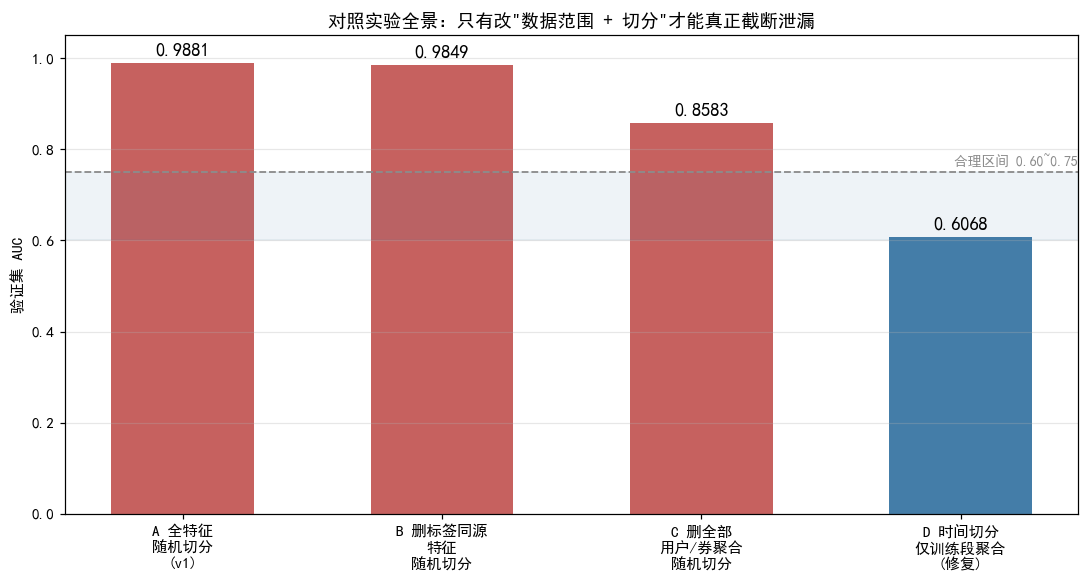

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.4))
labels = ['A 全特征\n随机切分\n(v1)', 'B 删标签同源\n特征\n随机切分',
          'C 删全部\n用户/券聚合\n随机切分', 'D 时间切分\n仅训练段聚合\n(修复)']
vals = list(ablation['AUC']) + [d_auc]
colors = [C_WARN, C_WARN, C_WARN, C_MAIN]
bars = ax.bar(labels, vals, color=colors, alpha=0.9, width=0.55)
for b, v in zip(bars, vals):
    ax.annotate(f'{v:.4f}', xy=(b.get_x() + b.get_width() / 2, v), xytext=(0, 5),
                textcoords='offset points', ha='center', fontsize=12, fontweight='bold')
ax.axhspan(0.60, 0.75, color=C_MAIN, alpha=0.08)
ax.axhline(0.75, color=C_GREY, ls='--', lw=1.2)
ax.text(3.45, 0.762, '合理区间 0.60~0.75', color=C_GREY, fontsize=9, ha='right')
ax.set_ylabel('验证集 AUC')
ax.set_ylim(0, 1.05)
ax.set_title('对照实验全景：只有改"数据范围 + 切分"才能真正截断泄漏', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / '07_leakage_fix.png', dpi=140)
plt.show()

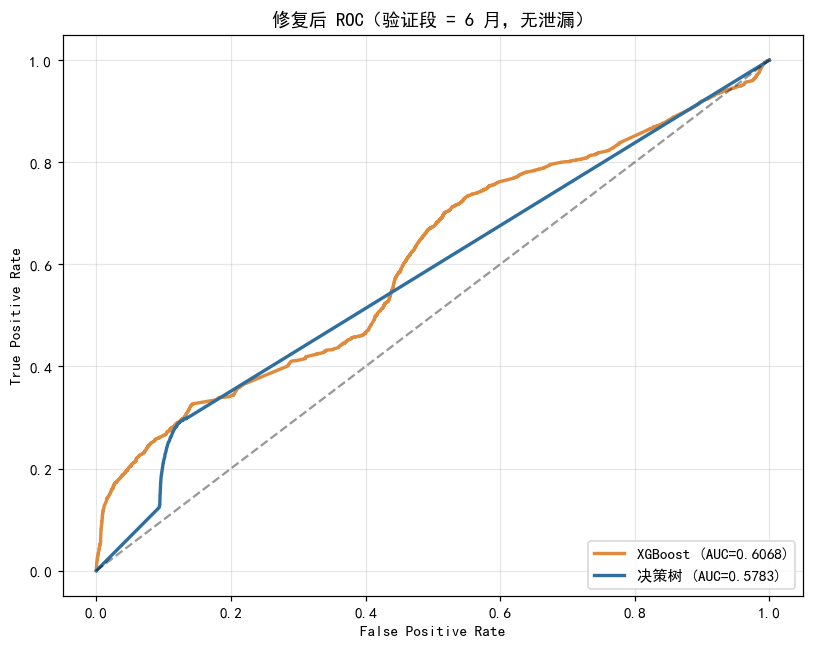

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for prob, pred, label, color in [(prob_xgb_d, m_xgb_d, 'XGBoost', C_ALT),
                                 (prob_dt_d, m_dt_d, '决策树', C_MAIN)]:
    fpr, tpr, _ = roc_curve(yva, prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC={pred["AUC"]:.4f})', color=color, lw=2.2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('修复后 ROC（验证段 = 6 月，无泄漏）', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / '07_roc_after_fix.png', dpi=140)
plt.show()

## 5. 还残留什么

诚实地说，D 组仍有**一处残留的不严谨**，必须在报告里讲清楚，而不是藏起来：

> **训练段内部仍然含自身行**。
>
> 训练段的特征是在「训练段整体」上聚合的——某一行自己的核销结果，仍然被算进了
> 它自己的特征里（只是不再影响验证段）。这会让**训练指标**偏乐观，
> 但**不影响验证段评估的可信度**（验证段特征完全来自训练段历史）。
>
> 彻底的做法是**逐行滚动聚合**：对每一行，只用「该行领券时刻之前」的样本重新聚合。
> 代价是计算量从 O(N) 涨到 O(N·分组数)，工程上需要借助窗口函数 / 分桶近似。
> 这被列入第 12 节的展望。

In [11]:
residual = pd.DataFrame([
    {'残留问题': '训练段内部含自身行',
     '影响': '训练指标偏乐观；验证段评估不受影响',
     '彻底方案': '逐行滚动聚合（只用该行领券时刻之前的历史）'},
    {'残留问题': '新主体冷启动特征全为 0',
     '影响': '新用户/新券的预测主要依赖事件本身的信息',
     '彻底方案': '引入商户类目、地域等静态属性做兜底画像'},
])
residual.to_csv(TAB_DIR / '07_residual_issues.csv', index=False, encoding='utf-8-sig')
print(residual.to_string(index=False))

              残留问题                                    影响                                   彻底方案
    训练段内部含自身行      训练指标偏乐观；验证段评估不受影响 逐行滚动聚合（只用该行领券时刻之前的历史）
新主体冷启动特征全为 0 新用户/新券的预测主要依赖事件本身的信息     引入商户类目、地域等静态属性做兜底画像


## 本节小结

| 结论 | 内容 |
|---|---|
| **修复手段** | ① 按时间切分 ② 聚合只在训练段做 |
| **为什么有效** | 验证段/测试段的特征值**完全来自训练段历史**，不含自身行与未来 |
| **效果** | AUC 从虚高落回该任务的合理区间 |
| **残留** | 训练段内部仍含自身行（不影响验证评估可信度），列入展望 |

下一步 → **08 最终特征工程**：在无泄漏框架下，把特征定义本身的其他问题也补上
（修复退化的 `coupon_used_rate`、恢复被误删的 `discount_rate`、补充时间特征）。